## Data Import

##### Library Import

In [245]:
import numpy as np
import pandas as pd 
import os
import random
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_auto
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools
from scipy.stats import mannwhitneyu
import warnings
import mne
import peakutils

init_notebook_mode(connected=True) ## plotly init
seed = 123
random.seed = seed

##### File Import

In [73]:
warnings.filterwarnings("ignore", category=FutureWarning) # disable future warnings
path_to_filtered_data = './data/processed/EEG_filtered.csv'
path_to_raw_data = './data/raw_formatted/EEG_formatted.csv'
filt_EEG_data = pd.read_csv(path_to_filtered_data)
raw_EEG_data = pd.read_csv(path_to_raw_data)

## remove the unused column
filt_EEG_data = filt_EEG_data.drop(['Unnamed: 0'], axis=1) 
raw_EEG_data = raw_EEG_data.drop(['Unnamed: 0'], axis=1) 

##### Variable Definitions

In [171]:
channel_list = filt_EEG_data['sensor position'].unique().tolist()
channel_map = {channel:counter for counter,channel in enumerate(channel_list)}
channel_map_mne = {
    'AFZ':'AFz', 
    'CPZ':'CPz', 
    'CZ':'Cz', 
    'FCZ':'FCz', 
    'FP1':'Fp1',
    'FP2':'Fp2', 
    'FPZ':'Fpz', 
    'FZ':'Fz', 
    'OZ':'Oz', 
    'POZ':'POz', 
    'PZ':'Pz',
}

## Signal Preprocessing

##### Testing

In [83]:
len(filt_EEG_data[['name', 'trial number', 'matching condition', 'sensor position']].drop_duplicates().index)

28548

##### Function Definitions

In [94]:
def get_record_df_og(df, name, trial_number, matching_condition, channel_list):
    df_record = df[df['name'].eq(name) & df['trial number'].eq(trial_number) & df['matching condition'].eq(matching_condition)].set_index(['sensor position']).loc[channel_list]
    return df_record

def get_signal_array_og(df, name, trial_number, matching_condition, channel_list):
    df_record = get_record_df_og(df, name, trial_number, matching_condition, channel_list)
    return df_record.to_numpy()[:, 4:]

def get_mne_raw_obs(signal_array, channel_list, channel_map_mne):
    # divide by 1000000 because mne raw interprets it as uV
    sig_divided = signal_array / 1e6

    info = mne.create_info(ch_names=channel_list, sfreq=256, ch_types=['eeg']*61)
    mne.rename_channels(info, channel_map_mne)
    raw = mne.io.RawArray(sig_divided, info)
    
    standard_1020_montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(standard_1020_montage)

    return raw

def filter_signal(signal_array, channel_list, channel_map_mne):
    # raw
    temp_raw = get_mne_raw_obs(signal_array, channel_list, channel_map_mne)
    # notch
    raw_notch = temp_raw.copy().notch_filter(freqs=50, phase='zero', verbose=False)
    # bandpass
    raw_bp = raw_notch.copy().filter(l_freq=0.5, h_freq=32, phase='zero',verbose=False)
    
    # set Cz reference EEG
    # raw_ref = raw_bp.copy().set_eeg_reference(ref_channels=['Cz']) 
    # set average reference EEG
    raw_ref_avg = raw_bp.copy().set_eeg_reference(ref_channels='average')
    # set REST reference EEG
    sphere = mne.make_sphere_model("auto", "auto", raw_bp.info, verbose=False)
    src = mne.setup_volume_source_space(sphere=sphere, exclude=30.0, pos=15.0, verbose=False)
    forward = mne.make_forward_solution(raw_bp.info, trans=None, src=src, bem=sphere, verbose=False)
    raw_ref_REST = raw_bp.copy().set_eeg_reference(ref_channels='REST', forward=forward) 
    
    # convert to np arr
    ref_avg_arr = np.transpose(raw_ref_avg.to_data_frame().to_numpy()[:,1:])
    ref_REST_arr = np.transpose(raw_ref_REST.to_data_frame().to_numpy()[:,1:])

    return ref_avg_arr, ref_REST_arr

def filter_dataframe(df, channel_list, channel_map_mne):
    # Create a copy of the DataFrame to avoid modifying the original data
    df_filtered_avg = df.copy()
    df_filtered_REST = df.copy()

    # Get unique combinations of 'name', 'trial number', 'matching condition', and 'sensor position'
    unique_combinations = df_filtered_avg[['name', 'trial number', 'matching condition', 'sensor position']].drop_duplicates()
    iter_len = len(filt_EEG_data[['name', 'trial number', 'matching condition', 'sensor position']].drop_duplicates().index)

    for _, row in tqdm_auto(unique_combinations.iterrows(), total=iter_len):
        
        # initial matching condition to initialize variables
        if row['sensor position'] == 'AF3':
            name = row['name']
            trial_number = row['trial number']
            matching_condition = row['matching condition']
            
            # Apply the filtering function
            signal_array = get_signal_array_og(df, name, trial_number, matching_condition, channel_list)
            filtered_signal_avg, filtered_signal_REST = filter_signal(signal_array, channel_list, channel_map_mne)
        
        mask = (
            (df_filtered_avg['name'] == name) &
            (df_filtered_avg['trial number'] == trial_number) &
            (df_filtered_avg['matching condition'] == matching_condition) &
            (df_filtered_avg['sensor position'] == row['sensor position'])
        )
        
        # get index of dataframe
        idx_df = df_filtered_avg.loc[mask].index.tolist()[0]

        # replace the data
        df_filtered_avg.iloc[idx_df, 5:261] = filtered_signal_avg[idx_df % 61].tolist()
        df_filtered_REST = df_filtered_avg.copy()
        df_filtered_REST.iloc[idx_df, 5:261] = filtered_signal_REST[idx_df % 61].tolist()

    return df_filtered_avg, df_filtered_REST

##### Function Execution

In [95]:
filt_EEG_data_avg_ref, filt_EEG_data_REST_ref = filter_dataframe(filt_EEG_data, channel_list, channel_map_mne)

  0%|          | 0/28548 [00:00<?, ?it/s]

Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    61 out of 61 channels remain after picking
Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    61 out of 61 channels remain after picking
Creating RawArray with float64 data, n_channels=61, n_times=256
    Range : 0 ... 255 =      0.000 ...     0.996 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('

##### Export Data

In [97]:
filt_EEG_data_avg_ref.to_csv('./data/processed_alt/EEG_filtered_avg.csv')
filt_EEG_data_REST_ref.to_csv('./data/processed_alt/EEG_filtered_REST.csv')

## Signal Averaging

##### Testing

In [19]:
df = filt_EEG_data
df[df['name'] == 'co2a0000372'].groupby('matching condition')['trial number'].nunique().sum()

df[df['name'] == 'co2a0000372'].groupby('matching condition')['trial number'].nunique().reset_index().iloc[0]['trial number']

del(df)

##### Function Definitions

In [102]:
# summing trials per name, per condition, per sensor position
def sum_trials(df, channel_list):
    # variable definitions
    col_names = pd.DataFrame(columns=df.columns).drop(['trial number'], axis=1).drop(['matching condition'], axis=1)
    sen_vals_names = df.columns[-256:]
    matched_cond_list = ['S1 obj', 'S2 match', 'S2 nomatch']
    avg_df_list = []
    
    # sum of sensors in grouping of matching condition per subject name per sensor
    summed_sensor_values_df = df.groupby(['name', 'matching condition', 'sensor position']).sum()

    for name_counter, name in tqdm_auto(enumerate(df['name'].unique()), total=len(channel_list) + len(matched_cond_list) + len(df['name'].unique())):
        for mc_counter, mc in enumerate(matched_cond_list):
            mc_len = len(matched_cond_list)
            
            # Group by 'matching condition' and count unique 'trial number'
            df_name = df[df['name'] == name]
            condition_counts = df_name.groupby('matching condition')['trial number'].nunique().reset_index()    
            for channel_counter, channel in enumerate(channel_list):
                cl_len = len(channel_list)
                
                # find index
                idx_df = channel_counter + cl_len*(mc_counter + mc_len*(name_counter))

                # count number of trials per condition
                num_conditions = condition_counts.iloc[mc_counter]['trial number']

                # format DataFrame
                temp_df = pd.DataFrame(columns=col_names.columns, index=[0])
                temp_df['name'] = name
                temp_df['sensor position'] = channel
                temp_df['subject identifier'] = name[3]
                temp_df[sen_vals_names] = summed_sensor_values_df.iloc[idx_df, 2:261].div(num_conditions)

                # append to list
                avg_df_list.append(temp_df)
                # df_averaged['sample_0':'sample_255'] = summed_sensor_values_df.iloc[idx_df, 2:261].div(num_conditions)
            
            # print(idx_df)
    
    # create a matching condition average column
    # Generate the list
    df_averaged = pd.concat(avg_df_list)
    averaged_matching_conditions = [condition for condition in matched_cond_list for _ in range(61)] * 16
    df_averaged.insert(1, "averaged matching conditions", averaged_matching_conditions)

    # rearrange
    df_cols_list = ['name', 'averaged matching conditions', 'subject identifier', 'sensor position'] + sen_vals_names.to_list()
    df_averaged = df_averaged.reindex(columns = df_cols_list)

    return df_averaged


# summing all subjects per sensor position, per subject identifier, per matching averaged matching condition
def sum_subjects(df, channel_list):
    col_names = pd.DataFrame(columns=df.columns).drop(['name'], axis=1)
    sen_vals_names = df.columns[-256:]
    matched_cond_list = ['S1 obj', 'S2 match', 'S2 nomatch']
    si_list = ['a', 'c']
    avg_df_list = []

    # sum of sensors in grouping of sensor per SI per AMC
    summed_sensor_values_df = df.groupby(['sensor position', 'subject identifier', 'averaged matching conditions']).sum()
    # number of subjects for con and alc
    num_subjects = 8

    for channel_counter, channel in tqdm_auto(enumerate(channel_list), total=len(si_list) + len(matched_cond_list) + len(channel_list)):
        for si_counter, si in enumerate(si_list):
            si_len = len(si_list)
            for mc_counter, mc in enumerate(matched_cond_list):
                mc_len = len(matched_cond_list)
                
                # find index
                idx_df = mc_counter + mc_len*(si_counter + si_len*(channel_counter))

                # format DataFrame
                temp_df = pd.DataFrame(columns=col_names.columns, index=[0])
                temp_df['subject identifier'] = si
                temp_df['averaged matching conditions'] = mc
                temp_df['sensor position'] = channel
                temp_df[sen_vals_names] = summed_sensor_values_df.iloc[idx_df, 1:261].div(num_subjects)

                # append to list
                avg_df_list.append(temp_df)
    
    df_averaged = pd.concat(avg_df_list)
    df_cols_list = ['subject identifier', 'averaged matching conditions', 'sensor position'] + sen_vals_names.to_list()
    df_averaged = df_averaged.reindex(columns = df_cols_list)

    return df_averaged

##### Function Execution

In [74]:
avg_EEG_data = sum_subjects(sum_trials(filt_EEG_data, channel_list), channel_list)
raw_EEG_data = sum_subjects(sum_trials(raw_EEG_data, channel_list), channel_list)

0it [00:00, ?it/s]

60
121


1it [00:05,  5.86s/it]

182
243
304


2it [00:11,  5.66s/it]

...

15it [01:21,  5.35s/it]

2744
2805
2866


16it [01:27,  5.44s/it]

2927



C:\Users\chira\AppData\Local\Temp\ipykernel_34888\2133037279.py:44: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

61it [00:11,  5.53it/s]


In [103]:
avg_EEG_data_avg_ref = sum_subjects(sum_trials(filt_EEG_data_avg_ref, channel_list), channel_list)
avg_EEG_data_REST_ref = sum_subjects(sum_trials(filt_EEG_data_REST_ref, channel_list), channel_list)

  0%|          | 0/80 [00:00<?, ?it/s]

C:\Users\chira\AppData\Local\Temp\ipykernel_34888\825182096.py:45: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

C:\Users\chira\AppData\Local\Temp\ipykernel_34888\825182096.py:45: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



  0%|          | 0/66 [00:00<?, ?it/s]

##### Corrections

In [75]:
avg_EEG_data = avg_EEG_data.reset_index(drop=True)
raw_EEG_data = raw_EEG_data.reset_index(drop=True)

In [104]:
avg_EEG_data_avg_ref = avg_EEG_data_avg_ref.reset_index(drop=True)
avg_EEG_data_REST_ref = avg_EEG_data_REST_ref.reset_index(drop=True)

##### Export Data

In [35]:
avg_EEG_data.to_csv('./data/averaged/avg_EEG_filtered.csv')

In [106]:
avg_EEG_data_avg_ref.to_csv('./data/averaged_alt/avg_EEG_filtered_avg.csv')
avg_EEG_data_REST_ref.to_csv('./data/averaged_alt/REST_EEG_filtered_REST.csv')

## Plotting

##### Function Definitions

In [436]:
def get_record_df(df, si, channel_list):
    df_record_s1 = df[df['subject identifier'].eq(si) & df['averaged matching conditions'].eq('S1 obj')].set_index(['sensor position']).loc[channel_list]
    df_record_s2m = df[df['subject identifier'].eq(si) & df['averaged matching conditions'].eq('S2 match')].set_index(['sensor position']).loc[channel_list]
    df_record_s2nm = df[df['subject identifier'].eq(si) & df['averaged matching conditions'].eq('S2 nomatch')].set_index(['sensor position']).loc[channel_list]
    return [df_record_s1, df_record_s2m, df_record_s2nm]

def get_signal_array(df, si, channel_list):
    df_records = get_record_df(df, si, channel_list)
    return [df_records[0].to_numpy()[:, 4:], df_records[1].to_numpy()[:, 4:], df_records[2].to_numpy()[:, 4:]]

def peak_detection(signal_array):
    sample_P300 = 77
    peaks = [(np.max(signal[sample_P300:]), sample_P300 + np.argmax(signal[sample_P300:])) for signal in signal_array]
    return peaks

def peak_detection_V2(signals):
    sample_P300 = 77
    signals_with_nan = np.copy(signals)
    for i, signal in enumerate(signals):
        # Find the peak value for the current sensor
        peak_index = np.argmax(signal[sample_P300:])
        # Create a mask for non-peak values
        non_peak_mask = np.ones_like(signal, dtype=bool)  # Start with all True
        non_peak_mask[sample_P300 + peak_index] = False  # Set the peak to False
        # Replace non-peak values with NaN
        signals_with_nan[i, non_peak_mask] = np.nan
    return signals_with_nan

def plot_samples(alc_signal_array, con_signal_array, channels, channel_map):
    # 3 differnt subplots of 2 each
    # fig_s1, axs_s1 = plt.subplots(2, figsize=[9,10])
    fig_s2m, axs_s2m = plt.subplots(2, figsize=[9,10])
    fig_s2nm, axs_s2nm = plt.subplots(2, figsize=[9,10])
    
    for channel in channels:
        # axs_s1[0].plot(alc_signal_array[0][channel_map[channel]])
        # axs_s1[1].plot(con_signal_array[0][channel_map[channel]])
        axs_s2m[0].plot(alc_signal_array[1][channel_map[channel]])
        axs_s2m[1].plot(con_signal_array[1][channel_map[channel]])
        axs_s2nm[0].plot(alc_signal_array[2][channel_map[channel]])
        axs_s2nm[1].plot(con_signal_array[2][channel_map[channel]])
        
    ##################### labels and titles
    # axs_s1[0].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    # axs_s1[0].title.set_text("Alcoholic - S1")
    # axs_s1[1].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    # axs_s1[1].title.set_text("Control - S1")

    axs_s2m[0].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2m[0].title.set_text("Alcoholic - S2 Match")
    axs_s2m[1].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2m[1].title.set_text("Control - S2 Match")

    axs_s2nm[0].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2nm[0].title.set_text("Alcoholic - S2 No Match")
    axs_s2nm[1].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2nm[1].title.set_text("Control - S2 No Match")

    ################# LEGENDS
    # box = axs_s1[0].get_position()
    # axs_s1[0].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s1[0].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)
    # box = axs_s1[1].get_position()
    # axs_s1[1].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s1[1].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)

    box = axs_s2m[0].get_position()
    axs_s2m[0].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    axs_s2m[0].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)
    box = axs_s2m[1].get_position()
    axs_s2m[1].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    axs_s2m[1].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)

    box = axs_s2nm[0].get_position()
    axs_s2nm[0].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    axs_s2nm[0].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)
    box = axs_s2nm[1].get_position()
    axs_s2nm[1].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    axs_s2nm[1].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)

    ################### Plot Peaks
    for channel in channels:
        # axs_s1[0].plot(peak_detection_V2(alc_signal_array[0])[channel_map[channel]], marker='.', markersize=15, mfc='black')
        # axs_s1[1].plot(peak_detection_V2(con_signal_array[0])[channel_map[channel]], marker='.', markersize=15, mfc='black')
        axs_s2m[0].plot(peak_detection_V2(alc_signal_array[1])[channel_map[channel]], marker='.', markersize=15, mfc='black')
        axs_s2m[1].plot(peak_detection_V2(con_signal_array[1])[channel_map[channel]], marker='.', markersize=15, mfc='black')
        axs_s2nm[0].plot(peak_detection_V2(alc_signal_array[2])[channel_map[channel]], marker='.', markersize=15, mfc='black')
        axs_s2nm[1].plot(peak_detection_V2(con_signal_array[2])[channel_map[channel]], marker='.', markersize=15, mfc='black')

    ##################### AXIS
    # axs_s1[0].set_ylim([-10, 20])
    # axs_s1[1].set_ylim([-10, 20])
    axs_s2m[0].set_ylim([-10, 20])
    axs_s2m[1].set_ylim([-10, 20])
    axs_s2nm[0].set_ylim([-10, 20])
    axs_s2nm[1].set_ylim([-10, 20])

    ################# GRID
    # axs_s1[0].grid()
    # axs_s1[1].grid()
    axs_s2m[0].grid()
    axs_s2m[1].grid()
    axs_s2nm[0].grid()
    axs_s2nm[1].grid()

    ######################### Set X Ticks
    tick_positions = np.linspace(0, 255, num=11)  # 11 points from 0 to 1
    normalized_tick_labels = [str(round(tick/256, 1)) for tick in tick_positions] # tick labels 0.1 0.2 0.3 ...
    # Set the tick positions on the x-axis
    # axs_s1[0].set_xticks(tick_positions)
    # axs_s1[1].set_xticks(tick_positions)
    axs_s2m[0].set_xticks(tick_positions)
    axs_s2m[1].set_xticks(tick_positions)
    axs_s2nm[0].set_xticks(tick_positions)
    axs_s2nm[1].set_xticks(tick_positions)
    # set labels
    # axs_s1[0].set_xticklabels(normalized_tick_labels)
    # axs_s1[1].set_xticklabels(normalized_tick_labels)
    axs_s2m[0].set_xticklabels(normalized_tick_labels)
    axs_s2m[1].set_xticklabels(normalized_tick_labels)
    axs_s2nm[0].set_xticklabels(normalized_tick_labels)
    axs_s2nm[1].set_xticklabels(normalized_tick_labels)

    ############################# set xlim
    axs_s2m[0].set_xlim([77, 258])
    axs_s2m[1].set_xlim([77, 258])
    axs_s2nm[0].set_xlim([77, 258])
    axs_s2nm[1].set_xlim([77, 258])
    # fig_s2m.subplots_adjust(left=0, right=1)
    # fig_s2nm.subplots_adjust(left=0, right=1)

    ######################### plot v and h lines
    # vertical lines
    # axs_s1[0].vlines(77, -10, 20)
    # axs_s1[1].vlines(77, -10, 20)
    # axs_s2m[0].vlines(77, -10, 20)
    # axs_s2m[1].vlines(77, -10, 20)
    # axs_s2nm[0].vlines(77, -10, 20)
    # axs_s2nm[1].vlines(77, -10, 20)
    # horizontal lines
    # axs_s1[0].axhline(color='black', ls='--', lw=1)
    # axs_s1[1].axhline(color='black', ls='--', lw=1)
    axs_s2m[0].axhline(color='black', ls='--', lw=1)
    axs_s2m[1].axhline(color='black', ls='--', lw=1)
    axs_s2nm[0].axhline(color='black', ls='--', lw=1)
    axs_s2nm[1].axhline(color='black', ls='--', lw=1)


def plot_samples_all(alc_signal_array, con_signal_array, channels, channel_map):
    # 3 differnt subplots of 2 each
    fig_s1, axs_s1 = plt.subplots(2, figsize=[15,10])
    fig_s2m, axs_s2m = plt.subplots(2, figsize=[15,10])
    fig_s2nm, axs_s2nm = plt.subplots(2, figsize=[15,10])
    
    for channel in channels:
        axs_s1[0].plot(alc_signal_array[0][channel_map[channel]])
        axs_s1[1].plot(con_signal_array[0][channel_map[channel]])
        axs_s2m[0].plot(alc_signal_array[1][channel_map[channel]])
        axs_s2m[1].plot(con_signal_array[1][channel_map[channel]])
        axs_s2nm[0].plot(alc_signal_array[2][channel_map[channel]])
        axs_s2nm[1].plot(con_signal_array[2][channel_map[channel]])
        
    ##################### labels and titles
    axs_s1[0].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s1[0].title.set_text("Alcoholic - S1")
    axs_s1[1].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s1[1].title.set_text("Control - S1")

    axs_s2m[0].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2m[0].title.set_text("Alcoholic - S2 Match")
    axs_s2m[1].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2m[1].title.set_text("Control - S2 Match")

    axs_s2nm[0].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2nm[0].title.set_text("Alcoholic - S2 No Match")
    axs_s2nm[1].set(xlabel='Time (s)', ylabel='Amplitude (uV)')
    axs_s2nm[1].title.set_text("Control - S2 No Match")

    ################# LEGENDS
    # box = axs_s1[0].get_position()
    # axs_s1[0].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s1[0].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)
    # box = axs_s1[1].get_position()
    # axs_s1[1].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s1[1].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)

    # box = axs_s2m[0].get_position()
    # axs_s2m[0].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s2m[0].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)
    # box = axs_s2m[1].get_position()
    # axs_s2m[1].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s2m[1].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)

    # box = axs_s2nm[0].get_position()
    # axs_s2nm[0].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s2nm[0].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)
    # box = axs_s2nm[1].get_position()
    # axs_s2nm[1].set_position([box.x0, box.y0, box.width * 1.8, box.height])    
    # axs_s2nm[1].legend(channels, loc='center left', bbox_to_anchor=(1, 0.5), ncols=5)

    ##################### AXIS
    axs_s1[0].set_ylim([-10, 20])
    axs_s1[1].set_ylim([-10, 20])
    axs_s2m[0].set_ylim([-10, 20])
    axs_s2m[1].set_ylim([-10, 20])
    axs_s2nm[0].set_ylim([-10, 20])
    axs_s2nm[1].set_ylim([-10, 20])

    ################# GRID
    axs_s1[0].grid()
    axs_s1[1].grid()
    axs_s2m[0].grid()
    axs_s2m[1].grid()
    axs_s2nm[0].grid()
    axs_s2nm[1].grid()

    ######################### Set X Ticks
    tick_positions = np.linspace(0, 255, num=11)  # 11 points from 0 to 1
    normalized_tick_labels = [str(round(tick/256, 1)) for tick in tick_positions] # tick labels 0.1 0.2 0.3 ...
    # Set the tick positions on the x-axis
    axs_s1[0].set_xticks(tick_positions)
    axs_s1[1].set_xticks(tick_positions)
    axs_s2m[0].set_xticks(tick_positions)
    axs_s2m[1].set_xticks(tick_positions)
    axs_s2nm[0].set_xticks(tick_positions)
    axs_s2nm[1].set_xticks(tick_positions)
    # set labels
    axs_s1[0].set_xticklabels(normalized_tick_labels)
    axs_s1[1].set_xticklabels(normalized_tick_labels)
    axs_s2m[0].set_xticklabels(normalized_tick_labels)
    axs_s2m[1].set_xticklabels(normalized_tick_labels)
    axs_s2nm[0].set_xticklabels(normalized_tick_labels)
    axs_s2nm[1].set_xticklabels(normalized_tick_labels)

    ######################### plot v and h lines
    # vertical lines
    # axs_s1[0].vlines(77, -10, 20)
    # axs_s1[1].vlines(77, -10, 20)
    # axs_s2m[0].vlines(77, -10, 20)
    # axs_s2m[1].vlines(77, -10, 20)
    # axs_s2nm[0].vlines(77, -10, 20)
    # axs_s2nm[1].vlines(77, -10, 20)
    # horizontal lines
    axs_s1[0].axhline(color='black', ls='--', lw=1)
    axs_s1[1].axhline(color='black', ls='--', lw=1)
    axs_s2m[0].axhline(color='black', ls='--', lw=1)
    axs_s2m[1].axhline(color='black', ls='--', lw=1)
    axs_s2nm[0].axhline(color='black', ls='--', lw=1)
    axs_s2nm[1].axhline(color='black', ls='--', lw=1)


def get_stats(alc_signal_array, con_signal_array, channels, channel_list):
    # finds peaks after .3s 61 rows (61 electrodes)
    # each row contains tuple of value, index
    alc_s2m_peaks = peak_detection(alc_signal_array[1])
    con_s2m_peaks = peak_detection(con_signal_array[1])
    alc_s2nm_peaks = peak_detection(alc_signal_array[2])
    con_s2nm_peaks = peak_detection(con_signal_array[2])

    # unzip vals
    alc_s2m_max_vals, alc_s2m_max_pos = zip(*alc_s2m_peaks)
    con_s2m_max_vals, con_s2m_max_pos = zip(*con_s2m_peaks)
    alc_s2nm_max_vals, alc_s2nm_max_pos = zip(*alc_s2nm_peaks)
    con_s2nm_max_vals, con_s2nm_max_pos = zip(*con_s2nm_peaks)

    # convert to time and round
    alc_s2m_max_pos = np.round(np.divide(alc_s2m_max_pos, 256), decimals=4)
    con_s2m_max_pos = np.round(np.divide(con_s2m_max_pos, 256), decimals=4)
    alc_s2nm_max_pos = np.round(np.divide(alc_s2nm_max_pos, 256), decimals=4)
    con_s2nm_max_pos = np.round(np.divide(con_s2nm_max_pos, 256), decimals=4)

    # create DFs with differentials
    df_s2m = pd.DataFrame({
        'Amplitude (uV)': np.round(alc_s2m_max_vals, decimals=4),
        'Time (s)': alc_s2m_max_pos,
        'Amplitude (uV)1': np.round(con_s2m_max_vals, decimals=4),
        'Time (s)1': con_s2m_max_pos,
        'Amplitude (uV)2': np.round([v1 - v2 for v1, v2 in zip(alc_s2m_max_vals, con_s2m_max_vals)], decimals=4),
        'Time (s)2': np.round([p1 - p2 for p1, p2 in zip(alc_s2m_max_pos, con_s2m_max_pos)], decimals=4),
    }, index=channel_list)
    df_s2nm = pd.DataFrame({
        'Amplitude (uV)': np.round(alc_s2nm_max_vals, decimals=4),
        'Time (s)': alc_s2nm_max_pos,
        'Amplitude (uV)1': np.round(con_s2nm_max_vals, decimals=4),
        'Time (s)1': con_s2nm_max_pos,
        'Amplitude (uV)2': np.round([v1 - v2 for v1, v2 in zip(alc_s2nm_max_vals, con_s2nm_max_vals)], decimals=4),
        'Time (s)2': np.round([p1 - p2 for p1, p2 in zip(alc_s2nm_max_pos, con_s2nm_max_pos)], decimals=4),
    }, index=channel_list)

    # define columns for DFs
    stat_columns_s2m = [('Alcohol S2 Match', 'Amplitude (uV)'), ('Alcohol S2 Match', 'Time (s)'),
                        ('Control S2 Match', 'Amplitude (uV)'), ('Control S2 Match', 'Time (s)'),
                        ('Difference', 'Amplitude (uV)'), ('Difference', 'Time (s)')]
    stat_columns_s2nm = [('Alcohol S2 No Match', 'Amplitude (uV)'), ('Alcohol S2 No Match', 'Time (s)'),
                         ('Control S2 No Match', 'Amplitude (uV)'), ('Control S2 No Match', 'Time (s)'),
                         ('Difference', 'Amplitude (uV)'), ('Difference', 'Time (s)')]
    
    # add column, subcolumns
    df_s2m.columns = pd.MultiIndex.from_tuples(stat_columns_s2m)
    df_s2nm.columns = pd.MultiIndex.from_tuples(stat_columns_s2nm)
    
    # select only relevant channels
    df_s2m = df_s2m.loc[channels]
    df_s2nm = df_s2nm.loc[channels]

    # create average series'
    l_avg_s2m = [np.round(df_s2m['Alcohol S2 Match', 'Amplitude (uV)'].mean(), decimals=4),
                 np.round(df_s2m['Alcohol S2 Match', 'Time (s)'].mean(), decimals=4),
                 np.round(df_s2m['Control S2 Match', 'Amplitude (uV)'].mean(), decimals=4),
                 np.round(df_s2m['Control S2 Match', 'Time (s)'].mean(), decimals=4),
                 np.round(df_s2m['Difference', 'Amplitude (uV)'].mean(), decimals=4),
                 np.round(df_s2m['Difference', 'Time (s)'].mean(), decimals=4)]
    l_avg_s2nm = [np.round(df_s2nm['Alcohol S2 No Match', 'Amplitude (uV)'].mean(), decimals=4),
                  np.round(df_s2nm['Alcohol S2 No Match', 'Time (s)'].mean(), decimals=4),
                  np.round(df_s2nm['Control S2 No Match', 'Amplitude (uV)'].mean(), decimals=4),
                  np.round(df_s2nm['Control S2 No Match', 'Time (s)'].mean(), decimals=4),
                  np.round(df_s2nm['Difference', 'Amplitude (uV)'].mean(), decimals=4),
                  np.round(df_s2nm['Difference', 'Time (s)'].mean(), decimals=4)]
    
    
    # # display averages
    # print(f"Average S2M Amplitude Difference: {np.round(df_s2m['Difference', 'Amplitude (uV)'].mean(), decimals=4)}")
    # print(f"Average S2M Latency Difference: {np.round(df_s2m['Difference', 'Time (s)'].mean(), decimals=4)}")
    # print(f"Average S2NM Amplitude Difference: {np.round(df_s2nm['Difference', 'Amplitude (uV)'].mean(), decimals=4)}")
    # print(f"Average S2NM Latency Difference: {np.round(df_s2nm['Difference', 'Time (s)'].mean(), decimals=4)}")
    
    # add rows
    df_s2m.loc["Average"] = l_avg_s2m
    df_s2nm.loc["Average"] = l_avg_s2nm

    # display dataframe
    display(df_s2m)
    display(df_s2nm)

def plot_eeg_joint_topomap(signal_array, channel_list, save_path_animation=None, show_names=False, start_time=0.05, end_time=1, step_size=0.1):
    # select channel X,Y format
    montage = mne.channels.make_standard_montage('standard_1020')
    
    # remove channels that don't have X,Y positions
    ch_to_remove = []
    for ch in channel_list:
        if ch not in list(set(montage.ch_names).intersection(channel_list)):
            ch_to_remove.append(channel_list.index(ch))
    arr = np.delete(signal_array.copy(), ch_to_remove, axis=0)
    
    # create info+evoked objects
    info = mne.create_info(ch_names=list(set(montage.ch_names).intersection(channel_list)), sfreq=256, ch_types='eeg')
    evoked = mne.EvokedArray(arr, info)
    
    # set channel X,Y positions
    evoked.set_montage(montage)

    # plot img
    evoked.plot_joint()

def plot_samples_V2(alc_signal_array, con_signal_array, channel):
    # 1 subplots of 2
    fig, axs = plt.subplots(2)
    
    axs[0].plot(alc_signal_array[0][channel_map[channel]])
    axs[0].plot(alc_signal_array[1][channel_map[channel]])
    axs[0].plot(alc_signal_array[2][channel_map[channel]])
    axs[1].plot(con_signal_array[0][channel_map[channel]])
    axs[1].plot(con_signal_array[1][channel_map[channel]])
    axs[1].plot(con_signal_array[2][channel_map[channel]])
        
    axs[0].set(xlabel='Sample number')
    axs[0].title.set_text(f"Alcoholic - {channel}")
    axs[0].legend(['S1 obj', 'S2 match', 'S2 no match'], loc='upper center', bbox_to_anchor=(0.1, 1.05), fancybox=True, ncol=1)
    axs[1].set(xlabel='Sample number')
    axs[1].title.set_text(f"Control - {channel}")
    axs[1].legend(['S1 obj', 'S2 match', 'S2 no match'], loc='upper center', bbox_to_anchor=(0.1, 1.05), fancybox=True, ncol=1)
    
    plt.tight_layout()
    fig.set_size_inches(6, 5)

def at_V1(df, custom_channels, channel_list, channel_map):
    # alcoholic
    alc_signal_array = get_signal_array(df, 'a', channel_list)
    # control
    con_signal_array = get_signal_array(df, 'c', channel_list)

    # plot 
    plot_samples(alc_signal_array, con_signal_array, custom_channels, channel_map)
    # plot_samples_all(alc_signal_array, con_signal_array, custom_channels, channel_map)

    # get stat tables
    get_stats(alc_signal_array, con_signal_array, custom_channels, channel_list)

def at_V2(df, channel, channel_list):
    # alcoholic
    alc_signal_array = get_signal_array(df, 'a', channel_list)
    # control
    con_signal_array = get_signal_array(df, 'c', channel_list)

    # plot 
    plot_samples_V2(alc_signal_array, con_signal_array, channel)


##### Plotting Execution

Alcohol S2 Match          Control S2 Match              Difference  \
          Amplitude (uV) Time (s)   Amplitude (uV) Time (s) Amplitude (uV)   
AF3               1.1089   0.3242           0.9516   0.9297         0.1573   
AF4               1.2033   0.8828           1.0319   0.9336         0.1714   
AF7               1.2943   0.9492           0.2525   0.9219         1.0418   
AF8               0.3163   0.9570           0.4834   0.9805        -0.1671   
AFZ               1.4428   0.3008           0.9776   0.9297         0.4652   
...                  ...      ...              ...      ...            ...   
T7                0.5791   0.6445           0.5503   0.7305         0.0288   
T8                0.4742   0.6797           1.0766   0.6641        -0.6024   
TP7               0.6867   0.6445           1.6027   0.6719        -0.9159   
TP8               1.0714   0.6562           0.8297   0.6328         0.2417   
Average           1.9099   0.5760           2.5490   0.6384        -0.6391   

                  
        Time (s)  
AF3      -0.6055  
AF4      -0.0508  
AF7       0.0273  
AF8      -0.0235  
AFZ      -0.6289  
...          ...  
T7       -0.0860  
T8        0.0156  
TP7      -0.0274  
TP8       0.0234  
Average  -0.0625  

[62 rows x 6 columns]

Alcohol S2 No Match          Control S2 No Match           \
             Amplitude (uV) Time (s)      Amplitude (uV) Time (s)   
AF3                  2.2688   0.8008              0.8324   0.9062   
AF4                  2.0751   0.7656              1.4003   0.9062   
AF7                  2.8808   0.7891              1.6802   0.9023   
AF8                  3.5764   0.7969              1.8667   0.9062   
AFZ                  2.0346   0.7695              1.2537   0.9062   
...                     ...      ...                 ...      ...   
T7                   1.2957   0.6797              2.1764   0.7305   
T8                   1.1588   0.7344              2.9563   0.7461   
TP7                  1.9936   0.6680              3.3516   0.7266   
TP8                  0.1738   0.6406              2.6447   0.6797   
Average              1.7588   0.6327              2.3913   0.6518   

            Difference           
        Amplitude (uV) Time (s)  
AF3             1.4364  -0.1054  
AF4             0.6748  -0.1406  
AF7             1.2006  -0.1132  
AF8             1.7097  -0.1093  
AFZ             0.7809  -0.1367  
...                ...      ...  
T7             -0.8807  -0.0508  
T8             -1.7975  -0.0117  
TP7            -1.3580  -0.0586  
TP8            -2.4709  -0.0391  
Average        -0.6325  -0.0191  

[62 rows x 6 columns]

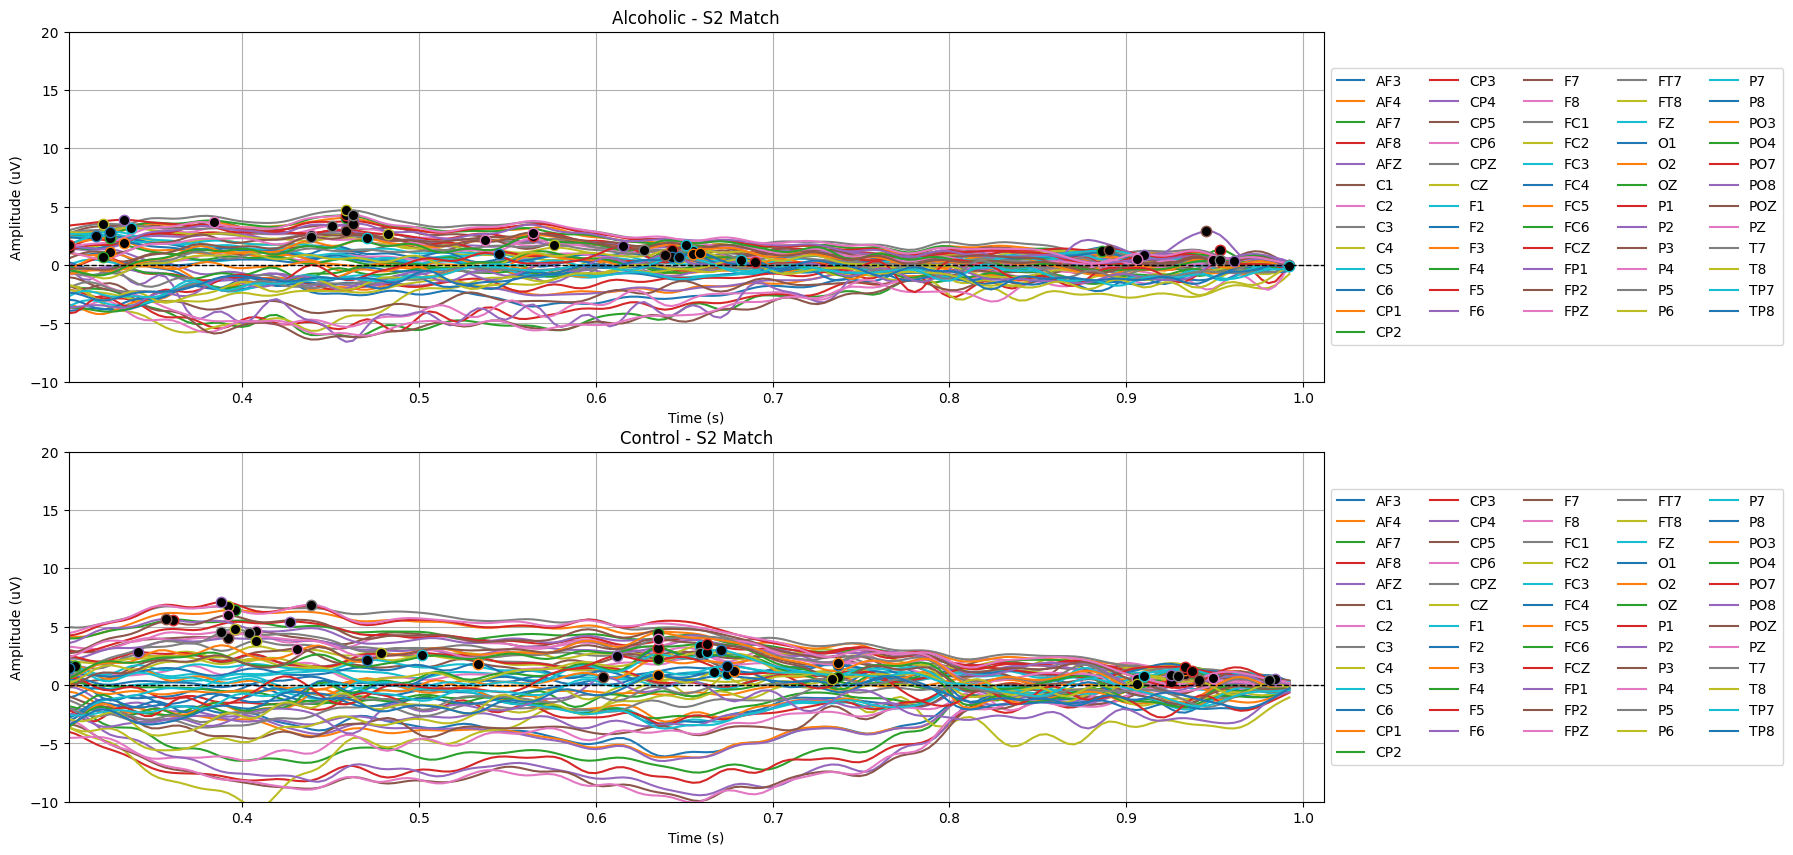

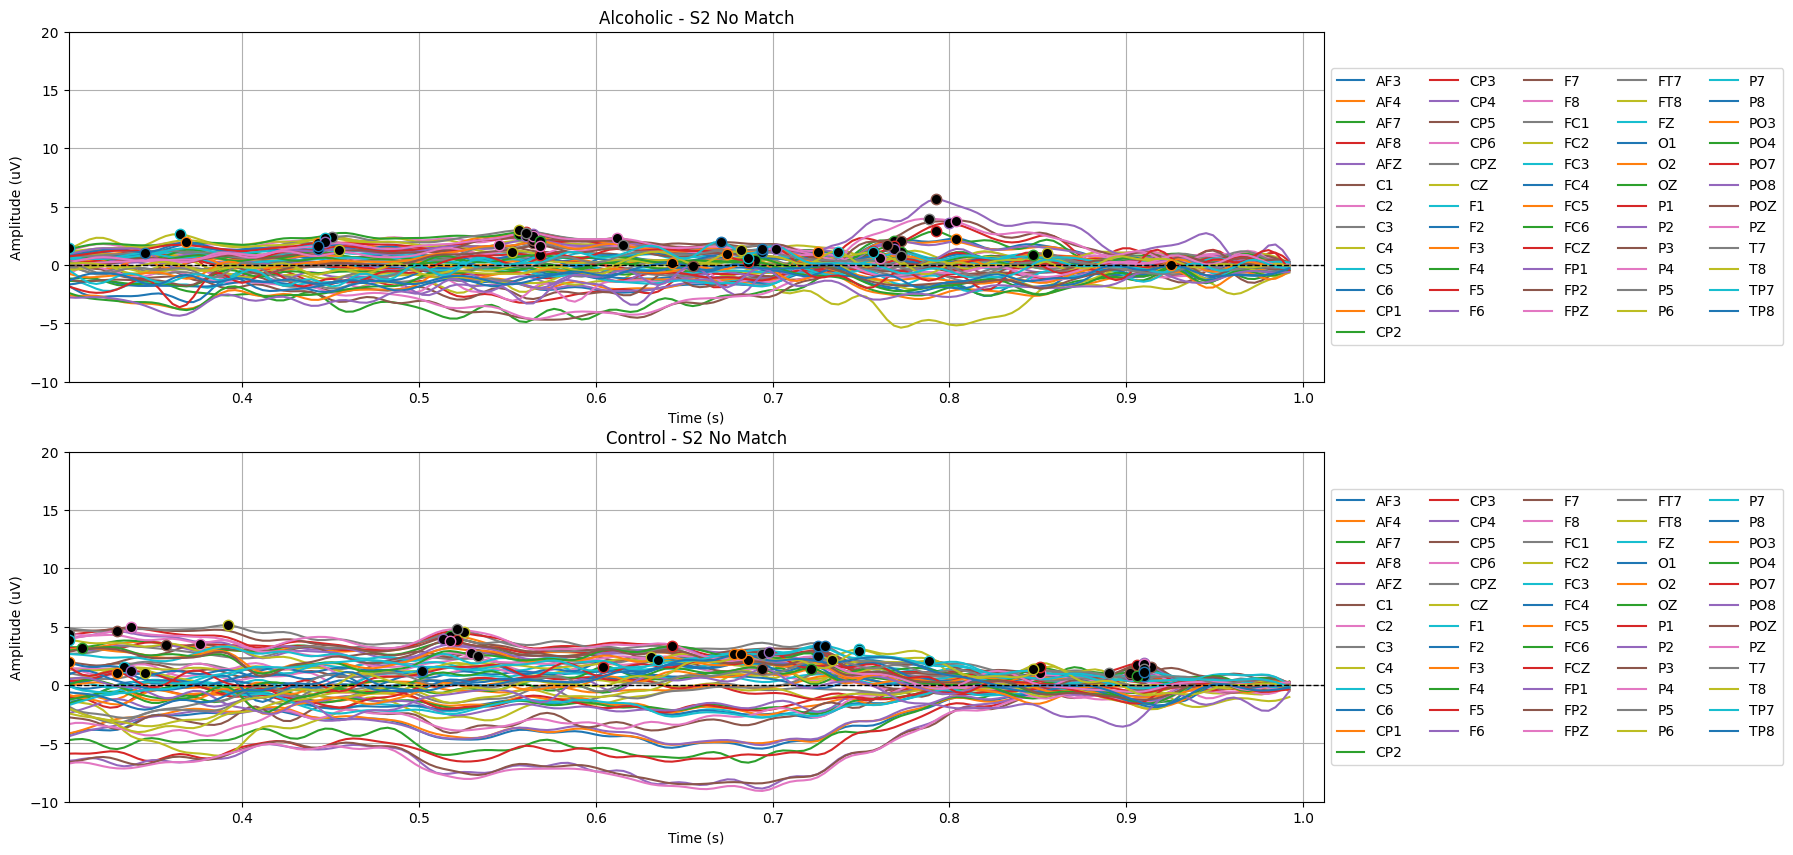

In [438]:
warnings.filterwarnings("ignore", category=RuntimeWarning) # disable future warnings

# from papers it looks like the following channels are best for EEG
channels_to_display_main = ['FP2', 'PO7', 'PO8', 'P6', 'P5']
# other channels
channels_to_display = ['AF3', 'AF4', 'AFZ', 'F1', 'F2']
channels_to_display_alt = ['FP1', 'FP2', 'AF3', 'AF4']

# channels testing
channels_testing = ['CP4', 'AFZ', 'F6', 'FP1', 'P2', 'PO8']
channels_testing_2 = ['AFZ','FP1']
channels_testing_P300 = ['FZ', 'PZ']

# according to [3]
ch_frontal_right = ['FP2', 'AF8', 'F8', 'FT8',
                    'AF4', 'F6',
                    'F4', 'F2']
ch_parietal = ['CP3', 'CP1', 'CP2', 'CP4',
               'P3', 'P1', 'PZ', 'P2', 'P4']

# experimental amongst markers
channels_markers_testing = ['C1', 'C2', 'C3', 'C4',
                            'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CPZ',
                            'FC5', 'FC6',
                            'O2', 'OZ',
                            'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7',
                            'PO4', 'PO7', 'PO8', 'POZ', 'PZ']

# sections of the brain
channels_central = ['C1', 'C2', 'C3', 'C4',
                    'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CPZ',
                    'FC5', 'FC6']
channels_parietal = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7',
                     'PO4', 'PO7', 'PO8', 'POZ', 'PZ']
channels_occipital = ['O1', 'O2', 'OZ']


# avg_EEG_data
# raw_EEG_data
# avg_EEG_data_avg_ref
# avg_EEG_data_REST_ref
at_V1(avg_EEG_data_REST_ref, custom_channels=channel_list, channel_list=channel_list, channel_map=channel_map)

# for ch in channel_list:
#     at_V2(sub_avg_EEG_data, ch, channel_list)

del(channels_to_display, channels_to_display_main, channels_testing, channels_testing_2, channels_testing_P300, channels_to_display_alt,
    ch_frontal_right, ch_parietal, channels_markers_testing, channels_central, channels_parietal, channels_occipital)

##### Testing

In [316]:
s1_temp, s2m_temp, s2nm_temp = get_signal_array(avg_EEG_data, 'a', channel_list)

# print(np.max(s1_temp[4][250:]))
# print(np.argmax(s1_temp[4][150:]))
# print(np.sort(s1_temp[4])[::-1])
# print(peak_detection_V2(s1_temp))
# print(s1_temp)


# print(channel_map_time)

del(s1_temp, s2m_temp, s2nm_temp)

['C1', 'C2', 'C3', 'C4', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CPZ', 'FC5', 'FC6', 'FT8', 'O2', 'OZ', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'PO4', 'PO7', 'PO8', 'POZ', 'PZ', 'T7', 'T8', 'TP7', 'TP8']
